# Section 5 — Entraînement par Imitation

**Fichier source** : `train_small.py`

---

## La boucle d'entraînement

On entraîne le modèle comme un **classificateur** : pour chaque état donné, prédire le bon nœud parmi les N+1 candidats.

```
Dataset (39 400 décisions)
    ↓  split 80/20 par seed (pas par exemple)
Train (31 500)  ──►  model(état) → logits → CrossEntropy(logits, oracle) → .backward()
Val   ( 7 900)  ──►  accuracy = % fois où argmax(logits) == oracle
```

Résultat de notre entraînement : **75% de val_acc** à l'epoch 19 — le modèle imite l'oracle correctement 3 décisions sur 4.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from build_decision_dataset import load_decision_dataset
from model import VRPTWAttentionModel
from train_small import DecisionDataset, collate_decisions, split_by_seed

# Charger l'historique d'entraînement
with open('artifacts_train_small/history.json') as f:
    history = json.load(f)

epochs     = [h['epoch']     for h in history]
train_loss = [h['train_loss'] for h in history]
val_loss   = [h['val_loss']   for h in history]
train_acc  = [h['train_acc']  for h in history]
val_acc    = [h['val_acc']    for h in history]
lrs        = [h['lr']         for h in history]

best_epoch = int(np.argmax(val_acc)) + 1
print(f"Epochs entraînés  : {len(history)}")
print(f"Meilleure val_acc : {max(val_acc):.2%}  à l'epoch {best_epoch}")

Epochs entraînés  : 50
Meilleure val_acc : 75.04%  à l'epoch 19


## 1. Split train / validation — `split_by_seed()`

Le split se fait **par seed d'instance**, pas par exemple individuel. C'est crucial :

```
❌ Mauvais split par exemple :
   Train : décisions 1,3,5,7 de l'instance seed=42
   Val   : décisions 2,4,6,8 de l'instance seed=42
   → Le modèle mémorise les instances → val_acc artificielle

✓ Bon split par seed :
   Train : toutes les décisions des seeds 0..799
   Val   : toutes les décisions des seeds 800..999
   → Le modèle est évalué sur des instances jamais vues
```

In [2]:
dataset = load_decision_dataset('decision_dataset_mixed.npy')
train_ex, val_ex, split = split_by_seed(dataset, val_ratio=0.2, split_seed=123)

print(f"Seeds totales       : {len(set(ex['seed'] for ex in dataset))}")
print(f"Seeds train         : {len(split.train_seeds)}  ({len(split.train_seeds)/len(set(ex['seed'] for ex in dataset)):.0%})")
print(f"Seeds val           : {len(split.val_seeds)}  ({len(split.val_seeds)/len(set(ex['seed'] for ex in dataset)):.0%})")
print()
print(f"Exemples train      : {split.train_examples:>6}  ({split.train_examples/len(dataset):.0%})")
print(f"Exemples val        : {split.val_examples:>6}  ({split.val_examples/len(dataset):.0%})")
print()
# Vérifier qu'aucune seed ne se retrouve dans les deux ensembles
overlap = set(split.train_seeds) & set(split.val_seeds)
print(f"Overlap train∩val   : {overlap}  (doit être vide ✓)")

Seeds totales       : 1000
Seeds train         : 800  (80%)
Seeds val           : 200  (20%)

Exemples train      :  31500  (80%)
Exemples val        :   7900  (20%)

Overlap train∩val   : set()  (doit être vide ✓)


## 2. Le collate — gérer les tailles variables

Le dataset mixte contient des exemples de taille n=10 et n=20 — les tenseurs n'ont pas la même forme. `torch.stack()` échouerait. On résout ça avec du **padding à zéro** :

```python
def collate_decisions(batch):
    max_nodes = max(x['node_features'].shape[0] for x in batch)  # 11 ou 21
    
    # Pad node_features  : (11, 7) → (21, 7)  avec des zéros
    # Pad action_features: (11, 5) → (21, 5)  avec des zéros
    # Pad feasible_mask  : (11,)   → (21,)    avec des zéros (= infaisable)
    
    return {tenseurs paddés et stackés en batch}
```

Les nœuds paddés ont un `feasible_mask = 0` → le modèle leur attribue un logit de `-∞` → ils n'influencent jamais la décision.

In [3]:
# Illustrer le padding
ex_n10 = next(ex for ex in dataset if ex['n'] == 10)
ex_n20 = next(ex for ex in dataset if ex['n'] == 20)

print("Avant collate :")
print(f"  Exemple n=10 : node_features.shape = {ex_n10['node_features'].shape}  (11 nœuds)")
print(f"  Exemple n=20 : node_features.shape = {ex_n20['node_features'].shape}  (21 nœuds)")

batch = collate_decisions([
    {k: torch.tensor(v) if isinstance(v, np.ndarray) else torch.tensor(v)
     for k, v in ex.items()
     if k in ['node_features','action_features','current_node','dynamic_global','feasible_mask','target_next_node']}
    for ex in [ex_n10, ex_n20]
])

print()
print("Après collate (batch de 2) :")
for k, v in batch.items():
    print(f"  {k:<20} : {list(v.shape)}")

print()
print(f"feasible_mask[0] (n=10, paddé) : {batch['feasible_mask'][0].numpy()}")
print(f"  → positions 11..20 = 0.0 (nœuds fantômes, logit = -∞)")

Avant collate :
  Exemple n=10 : node_features.shape = (11, 7)  (11 nœuds)
  Exemple n=20 : node_features.shape = (21, 7)  (21 nœuds)

Après collate (batch de 2) :
  node_features        : [2, 21, 7]
  action_features      : [2, 21, 5]
  current_node         : [2]
  dynamic_global       : [2, 6]
  feasible_mask        : [2, 21]
  target_next_node     : [2]

feasible_mask[0] (n=10, paddé) : [1. 1. 0. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  → positions 11..20 = 0.0 (nœuds fantômes, logit = -∞)


## 3. La fonction de perte — Cross-Entropy

```python
loss = CrossEntropyLoss(logits, target_next_node)
```

La Cross-Entropy mesure **à quel point le modèle était confiant dans le bon choix** :

```
loss = -log(softmax(logits)[target])
```

- Si le modèle donne logit=10 au bon nœud → softmax ≈ 1.0 → loss ≈ 0
- Si le modèle donne logit=0 à tous → softmax = 1/N → loss = log(N)
- Si le modèle donne logit élevé au mauvais nœud → loss élevée

Le gradient de la loss dit au modèle : *"augmente le score du nœud oracle, diminue le score des autres"*.

In [4]:
# Illustrer la cross-entropy
loss_fn = nn.CrossEntropyLoss()

print("Exemples de Cross-Entropy loss :")
print()

scenarios = [
    ("Modèle parfait",      [5.0, -1e9, -1e9, -1e9], 0),
    ("Modèle confiant OK",  [3.0,  0.0,  0.0,  0.0], 0),
    ("Modèle incertain",    [1.0,  0.8,  0.9,  0.7], 0),
    ("Modèle se trompe",    [-1.0, 3.0,  0.0,  0.0], 0),
]

for desc, logits_ex, target in scenarios:
    l = torch.tensor([logits_ex], dtype=torch.float32)
    t = torch.tensor([target],    dtype=torch.long)
    loss_val = loss_fn(l, t).item()
    probs = torch.softmax(l, dim=1)[0].numpy()
    print(f"  {desc:<22} | logits={[f'{x:.0f}' for x in logits_ex]}  p(oracle)={probs[0]:.3f}  loss={loss_val:.3f}")

Exemples de Cross-Entropy loss :

  Modèle parfait         | logits=['5', '-1000000000', '-1000000000', '-1000000000']  p(oracle)=1.000  loss=0.000
  Modèle confiant OK     | logits=['3', '0', '0', '0']  p(oracle)=0.870  loss=0.139
  Modèle incertain       | logits=['1', '1', '1', '1']  p(oracle)=0.289  loss=1.243
  Modèle se trompe       | logits=['-1', '3', '0', '0']  p(oracle)=0.016  loss=4.111


## 4. Optimiseur et scheduler

**AdamW** : variante d'Adam avec weight decay découplé. Meilleure régularisation pour les Transformers.

```python
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
```

**Cosine Annealing** : le learning rate descend de `lr` à `lr/100` suivant une courbe cosinus sur toute la durée. Permet une exploration large en début d'entraînement puis une convergence fine.

**Gradient clipping** (max_norm=1.0) : si les gradients explosent (ce qui arrive avec les Transformers), on les normalise. Indispensable pour la stabilité.

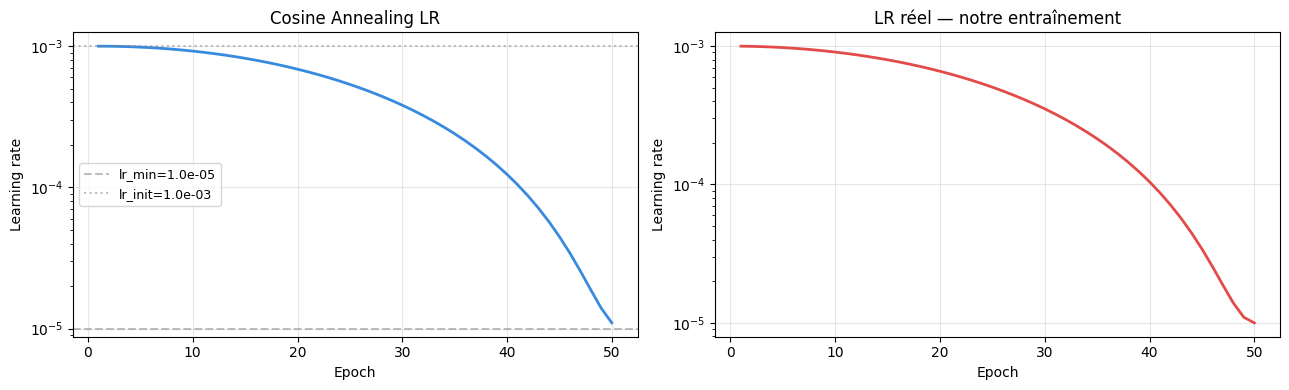

In [5]:
# Visualiser le scheduler cosine
lr_init = 1e-3
n_epochs = 50
lr_min = lr_init / 100
cosine_lrs = [lr_min + 0.5*(lr_init-lr_min)*(1 + np.cos(np.pi*e/n_epochs)) for e in range(n_epochs)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# LR schedule théorique
axes[0].plot(range(1, n_epochs+1), cosine_lrs, '#378ADD', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Learning rate')
axes[0].set_title('Cosine Annealing LR')
axes[0].set_yscale('log')
axes[0].axhline(lr_min, color='gray', linestyle='--', alpha=0.5, label=f'lr_min={lr_min:.1e}')
axes[0].axhline(lr_init, color='gray', linestyle=':', alpha=0.5, label=f'lr_init={lr_init:.1e}')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# LR réel de notre entraînement
axes[1].plot(epochs, lrs, '#E24B4A', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning rate')
axes[1].set_title('LR réel — notre entraînement')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Courbes d'apprentissage

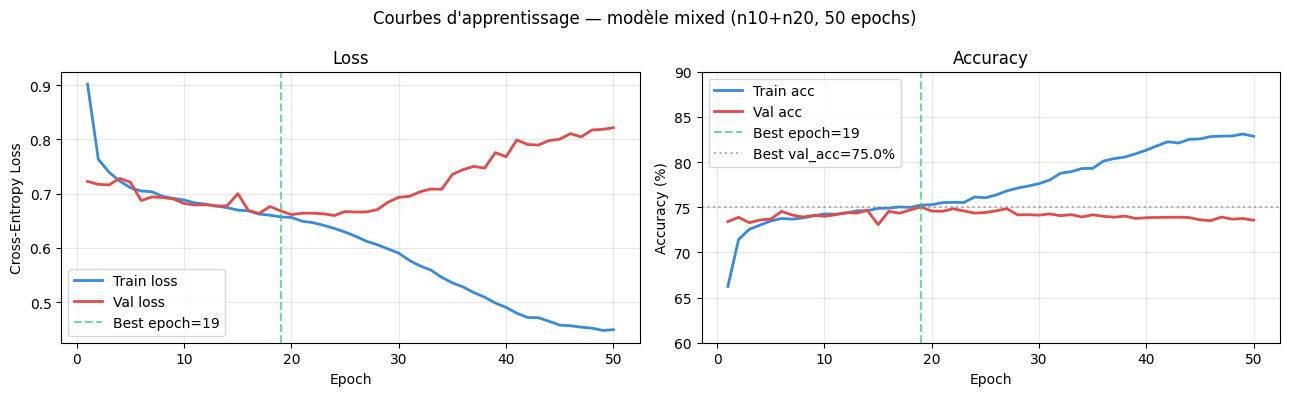

Epoch 1  → train=66.2%  val=73.4%
Epoch 19 → train=75.2%  val=75.0%  ← best
Epoch 50 → train=82.9%  val=73.6%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Courbes d\'apprentissage — modèle mixed (n10+n20, 50 epochs)', fontsize=12)

# Loss
axes[0].plot(epochs, train_loss, '#378ADD', linewidth=2, label='Train loss')
axes[0].plot(epochs, val_loss,   '#E24B4A', linewidth=2, label='Val loss')
axes[0].axvline(best_epoch, color='#2ECC71', linestyle='--', alpha=0.7, label=f'Best epoch={best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, [a*100 for a in train_acc], '#378ADD', linewidth=2, label='Train acc')
axes[1].plot(epochs, [a*100 for a in val_acc],   '#E24B4A', linewidth=2, label='Val acc')
axes[1].axvline(best_epoch, color='#2ECC71', linestyle='--', alpha=0.7, label=f'Best epoch={best_epoch}')
axes[1].axhline(max(val_acc)*100, color='gray', linestyle=':', alpha=0.6,
                label=f'Best val_acc={max(val_acc):.1%}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy')
axes[1].set_ylim(60, 90)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Epoch 1  → train={train_acc[0]:.1%}  val={val_acc[0]:.1%}")
print(f"Epoch {best_epoch:<2} → train={train_acc[best_epoch-1]:.1%}  val={val_acc[best_epoch-1]:.1%}  ← best")
print(f"Epoch 50 → train={train_acc[-1]:.1%}  val={val_acc[-1]:.1%}")

## 6. Lecture des courbes — overfitting

On observe un **overfitting léger** après l'epoch 19 :

- La **train_acc** continue de monter (82→83%) — le modèle mémorise de plus en plus le dataset d'entraînement
- La **val_acc** plafonne à 75% puis redescend légèrement — le modèle généralise moins bien

C'est pourquoi on sauvegarde **le checkpoint de la meilleure val_acc** (epoch 19), pas le dernier.

```python
if val_acc > best_val_acc:
    best_val_acc = val_acc
    torch.save(model.state_dict(), 'best_model.pt')  # ← sauvegarde seulement si meilleur
```

**Pourquoi 75% et pas 95% ?** Le VRPTW est un problème complexe avec beaucoup de décisions quasi-équivalentes — parfois plusieurs nœuds sont pratiquement aussi bons que l'oracle. L'accuracy de décision individuelle n'est pas le bon indicateur final : ce qui compte c'est la **qualité de la solution complète** (gap vs oracle).

In [7]:
best = max(history, key=lambda h: h['val_acc'])
print("=== Checkpoint sauvegardé ===")
print(f"  Epoch        : {best['epoch']}")
print(f"  Train loss   : {best['train_loss']:.4f}")
print(f"  Val loss     : {best['val_loss']:.4f}")
print(f"  Train acc    : {best['train_acc']:.2%}")
print(f"  Val acc      : {best['val_acc']:.2%}")
print(f"  LR à ce moment : {best['lr']:.2e}")

# Comparer avec l'état du modèle à différents moments
print()
print(f"{'Epoch':>6} | {'Train acc':>10} | {'Val acc':>9} | {'Gap overfit':>12}")
print("-" * 45)
for e in [1, 5, 10, best_epoch, 30, 40, 50]:
    h = history[e-1]
    gap = h['train_acc'] - h['val_acc']
    marker = ' ← BEST' if e == best_epoch else ''
    print(f"{e:>6} | {h['train_acc']:>10.2%} | {h['val_acc']:>9.2%} | {gap:>12.2%}{marker}")

=== Checkpoint sauvegardé ===
  Epoch        : 19
  Train loss   : 0.6572
  Val loss     : 0.6682
  Train acc    : 75.24%
  Val acc      : 75.04%
  LR à ce moment : 6.87e-04

 Epoch |  Train acc |   Val acc |  Gap overfit
---------------------------------------------
     1 |     66.23% |    73.42% |       -7.19%
     5 |     73.49% |    73.70% |       -0.21%
    10 |     74.27% |    74.00% |        0.27%
    19 |     75.24% |    75.04% |        0.21% ← BEST
    30 |     77.62% |    74.13% |        3.49%
    40 |     81.32% |    73.85% |        7.48%
    50 |     82.86% |    73.57% |        9.29%


## Récapitulatif

```
Dataset mixte (39 400 décisions)
        ↓  split_by_seed()  →  train (31 500) / val (7 900)
        ↓  collate_decisions()  →  padding à 21 nœuds, batch de 64

Pour chaque epoch :
  Pour chaque batch :
    logits = model(état)                  # forward
    loss   = CrossEntropy(logits, oracle) # mesure l'erreur
    loss.backward()                       # calcul des gradients
    clip_grad_norm(max=1.0)               # stabilité Transformer
    AdamW.step()                          # mise à jour des poids
  CosineAnnealing.step()                  # diminuer le LR
  if val_acc > best → save checkpoint

Résultat : best_model.pt  (epoch 19, val_acc = 75.0%)
         → Section 6 : inférence et décodage
```